In [45]:
# Imported Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
%matplotlib inline

# Step 1: Loaded Data

RATINGS_PATH = r"C:\Users\123\Documents\Movie_Recommendation\ratings.csv"
MOVIES_PATH  = r"C:\Users\123\Documents\Movie_Recommendation\movies.csv"


In [52]:

# ratings: userId,movieId,rating,timestamp
# movies:  movieId,title,genres
ratings = pd.read_csv(RATINGS_PATH)
movies  = pd.read_csv(MOVIES_PATH)

print("Ratings:", ratings.shape, "|", "Movies:", movies.shape)
display(ratings.head())
display(movies.head())


Ratings: (100836, 4) | Movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [47]:
# Cell 3 — Performed EDA: counts, averages, top lists (concise)

print("Rating value counts:\n", ratings['rating'].value_counts().sort_index())
print("\nUnique users:", ratings['userId'].nunique(), " Unique movies:", ratings['movieId'].nunique())

# Top 5 most-rated movies
movie_counts = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
top5 = movie_counts.head(5).reset_index().merge(movies, on='movieId')[['movieId','title','rating']]
print("\nTop 5 movies by number of ratings:")
display(top5)


Rating value counts:
 rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

Unique users: 610  Unique movies: 9724

Top 5 movies by number of ratings:


,movieId,title,rating
0,356,Forrest Gump (1994),329
1,318,"Shawshank Redemption, The (1994)",317
2,296,Pulp Fiction (1994),307
3,593,"Silence of the Lambs, The (1991)",279
4,2571,"Matrix, The (1999)",278


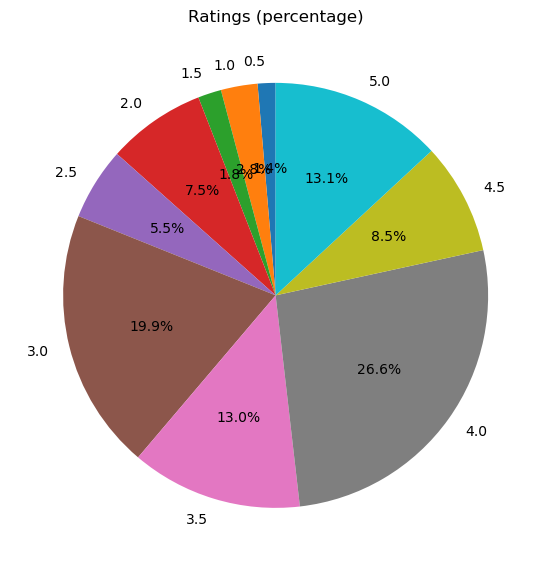

In [55]:
# Visualization

plt.figure(figsize=(22,12))  

# ⭐ .Pie chart - % of each rating (new)
plt.subplot(1,4,4)
rating_percent = ratings['rating'].value_counts().sort_index()
plt.pie(rating_percent, labels=rating_percent.index, autopct='%1.1f%%', startangle=90)
plt.title("Ratings (percentage)")

plt.tight_layout()
plt.show()


In [49]:
# Item-Item recommender
# Pivot to movie-title columns for readability
data = ratings.merge(movies[['movieId','title']], on='movieId', how='left')
user_item = data.pivot_table(index='userId', columns='title', values='rating')
user_item_filled = user_item.fillna(0)                 # fill NaN with 0 for similarity
item_user = user_item_filled.T                         # Transposes the matrix so that: Rows = movies, Columns = users 
# Now each row vector represents a movie’s ratings from all users

# compute item-item cosine similarity (movie-title indexed)
item_sim = cosine_similarity(item_user)
item_sim_df = pd.DataFrame(item_sim, index=item_user.index, columns=item_user.index)


In [50]:
# — Item-item recommender (movieId-based) and Top-N with metadata

# 1) Ensure we have a merged pivot based on movieId (users x movieId)
# If you already built a user_item (title-based), we recreate on movieId to be safe.
data_mid = ratings.merge(movies[['movieId','title']], on='movieId', how='left')

# Pivot: rows=userId, columns=movieId, values=rating (NaN where not rated)
user_item_mid = data_mid.pivot_table(index='userId', columns='movieId', values='rating')

# Fill zeros only for similarity computation (do not overwrite user_item_mid)
user_item_filled_mid = user_item_mid.fillna(0)

# Item-user matrix (rows = movieId, cols = userId)
item_user_mid = user_item_filled_mid.T

# Compute item-item cosine similarity (index & columns = movieId)
item_sim_mid = cosine_similarity(item_user_mid)
item_sim_df_mid = pd.DataFrame(item_sim_mid,
                               index=item_user_mid.index,
                               columns=item_user_mid.index)

# Precompute movie stats to show in output
movie_stats = ratings.groupby('movieId').agg(
    rating_count = ('rating','count'),
    rating_mean  = ('rating','mean')
).reset_index().set_index('movieId')

# Map movieId -> title (for easy lookup)
id_to_title = movies.set_index('movieId')['title'].to_dict()

# 2) Prediction function (movieId-based)
def predict_item_mid(user_id, movie_id, k=10):
    """
    Predict rating for (user_id, movie_id) using item-item CF (top-k similar movies user rated).
    Returns np.nan if prediction not possible.
    """
    # basic checks
    if movie_id not in item_sim_df_mid.index:
        return np.nan
    if user_id not in user_item_mid.index:
        return np.nan

    # movies this user has rated (movieId index)
    user_ratings = user_item_mid.loc[user_id].dropna()
    if user_ratings.empty:
        return np.nan

    # similarities between candidate movie and movies user rated
    sims = item_sim_df_mid[movie_id].loc[user_ratings.index]
    # top-k similar movies that user rated
    topk = sims.sort_values(ascending=False).iloc[:k]
    topk_ratings = user_ratings.loc[topk.index]

    if topk.sum() == 0:
        return np.nan

    # weighted average prediction
    pred = np.dot(topk.values, topk_ratings.values) / topk.sum()
    return pred

# 3) Top-N wrapper which returns metadata (title, movieId, predicted_score, avg_rating, rating_count)
def top_n_with_meta(user_id, n=10, k=10, min_rating_count=0):
    """ Returns DataFrame of top-n recommended movies for user_id with metadata.
    - min_rating_count: filter out movies with fewer than this many ratings (optional) """
    if user_id not in user_item_mid.index:
        print(f"UserId {user_id} not found in dataset.")
        return pd.DataFrame(columns=['movieId','title','predicted_score','avg_rating','rating_count'])

    # movies user has already rated
    seen = user_item_mid.loc[user_id].dropna().index.tolist()
    # candidate pool = all movies not seen
    candidates = [m for m in item_user_mid.index if m not in seen]

    # optional filter by popularity
    if min_rating_count > 0:
        candidates = [m for m in candidates if (movie_stats.loc[m]['rating_count'] if m in movie_stats.index else 0) >= min_rating_count]

    scored = []
    for m in candidates:
        p = predict_item_mid(user_id, m, k=k)
        if np.isnan(p):
            continue
        avg = movie_stats.loc[m]['rating_mean'] if m in movie_stats.index else np.nan
        cnt = int(movie_stats.loc[m]['rating_count']) if m in movie_stats.index else 0
        scored.append((m, id_to_title.get(m, "Unknown Title"), round(p,3), round(avg,3) if not np.isnan(avg) else np.nan, cnt))

    # sort and return top-n
    top = sorted(scored, key=lambda x: x[2], reverse=True)[:n]
    df = pd.DataFrame(top, columns=['movieId','title','predicted_score','avg_rating','rating_count'])
    return df
# 4) Interactive example: ask for a userId and show results
try:
    uid = int(input("Enter a userId to get recommendations: "))
    print(f"\nTop Recommendations for User-ID {uid} :\n")
    display(top_n_with_meta(uid, n=10, k=20, min_rating_count=0))
except ValueError:
    print("Please enter a valid integer userId.")


Enter a userId to get recommendations:  201



Top Recommendations for User-ID 201 :



,movieId,title,predicted_score,avg_rating,rating_count
0,1140,Entertaining Angels: The Dorothy Day Story (1996),5.0,5.00,1
1,1331,Audrey Rose (1977),5.0,2.00,1
2,1341,Burnt Offerings (1976),5.0,3.75,2
3,1477,Love Jones (1997),5.0,4.00,1
4,1519,Broken English (1996),5.0,1.00,1
5,1685,"I Love You, I Love You Not (1996)",5.0,3.00,1
6,1980,Friday the 13th Part VII: The New Blood (1988),5.0,2.00,1
7,2226,"Ring, The (1927)",5.0,1.00,1
8,2655,Howling II: Your Sister Is a Werewolf (1985),5.0,2.00,1
9,2740,"Kindred, The (1986)",5.0,1.00,1
